### <span style="color: Red;"> 1. **Overview of Problem Statement:**</span>

#### The hospitality industry depends on accurate forecasting of room prices and booking demand to optimize revenue and operational planning. However, these predictions are difficult due to the influence of seasonality, customer behavior, and market dynamics. Traditional methods often fail to capture these complex patterns. Hence, building a machine learning model to predict Average Daily Rate (ADR) and hotel booking demand can help hotels make data-driven pricing decisions and improve revenue management.

### <span style="color: Red;">2. **Objective:**</span>

#### The main objective of this project is to develop a machine learning model that can accurately predict hotel room prices (Average Daily Rate – ADR) and booking demand using historical hotel booking data.

### <span style="color: Red;"> 3. **Data Description:**</span>

### <span style="color: Blue;">Source</span>

#### The dataset used in this project is the Hotel Booking Demand Dataset, obtained from Kaggle.
#### Dataset Link: https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand
#### Original Research Authors:
#### Nuno Antonio,
#### Ana de Almeida,
#### Luis Nunes
#### The dataset contains real booking data for a Resort Hotel and a City Hotel located in Portugal, covering the period from July 2015 to August 2017.
### <span style="color: Blue;"> Features </span>
#### The dataset contains 32 features (columns) representing various aspects of hotel bookings. These include customer details, booking information, stay characteristics, and pricing data.
#### The features available in the dataset are:
#### 1. hotel
#### 2. is_canceled
#### 3. lead_time
#### 4. arrival_date_year
#### 5. arrival_date_month
#### 6. arrival_date_week_number
#### 7. arrival_date_day_of_month
#### 8. stays_in_weekend_nights
#### 9. stays_in_week_nights
#### 10. adults
#### 11. children
#### 12. babies
#### 13. meal
#### 14. country
#### 15. market_segment
#### 16. distribution_channel
#### 17. is_repeated_guest
#### 18. previous_cancellations
#### 19. previous_bookings_not_canceled
#### 20. reserved_room_type
#### 21. assigned_room_type
#### 22. booking_changes
#### 23. deposit_type
#### 24. agent
#### 25. company
#### 26. days_in_waiting_list
#### 27. customer_type
#### 28. adr (Average Daily Rate – Target Variable)
#### 29. required_car_parking_spaces
#### 30. total_of_special_requests
#### 31. reservation_status
#### 32. reservation_status_date

### <span style="color: Red;">4. **Data Collection:**</span>

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("hotel_bookings.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

### <span style="color: Red;">5. **Data Preprocessing - Data Cleaning:**</span>

##### Checking Total Number of Duplicate Rows

In [3]:
df.duplicated().sum()

np.int64(31994)

In [4]:
df[df.duplicated()]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
22,Resort Hotel,0,72,2015,July,27,1,2,4,2,...,No Deposit,250.0,NaN,0,Transient,84.67,0,1,Check-Out,2015-07-07
43,Resort Hotel,0,70,2015,July,27,2,2,3,2,...,No Deposit,250.0,NaN,0,Transient,137.00,0,1,Check-Out,2015-07-07
138,Resort Hotel,1,5,2015,July,28,5,1,0,2,...,No Deposit,240.0,NaN,0,Transient,97.00,0,0,Canceled,2015-07-01
200,Resort Hotel,0,0,2015,July,28,7,0,1,1,...,No Deposit,240.0,NaN,0,Transient,109.80,0,3,Check-Out,2015-07-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119349,City Hotel,0,186,2017,August,35,31,0,3,2,...,No Deposit,9.0,NaN,0,Transient,126.00,0,2,Check-Out,2017-09-03
119352,City Hotel,0,63,2017,August,35,31,0,3,3,...,No Deposit,9.0,NaN,0,Transient-Party,195.33,0,2,Check-Out,2017-09-03
119353,City Hotel,0,63,2017,August,35,31,0,3,3,...,No Deposit,9.0,NaN,0,Transient-Party,195.33,0,2,Check-Out,2017-09-03
119354,City Hotel,0,63,2017,August,35,31,0,3,3,...,No Deposit,9.0,NaN,0,Transient-Party,195.33,0,2,Check-Out,2017-09-03


In [5]:
df[df.duplicated(keep=False)]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
21,Resort Hotel,0,72,2015,July,27,1,2,4,2,...,No Deposit,250.0,NaN,0,Transient,84.67,0,1,Check-Out,2015-07-07
22,Resort Hotel,0,72,2015,July,27,1,2,4,2,...,No Deposit,250.0,NaN,0,Transient,84.67,0,1,Check-Out,2015-07-07
39,Resort Hotel,0,70,2015,July,27,2,2,3,2,...,No Deposit,250.0,NaN,0,Transient,137.00,0,1,Check-Out,2015-07-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119352,City Hotel,0,63,2017,August,35,31,0,3,3,...,No Deposit,9.0,NaN,0,Transient-Party,195.33,0,2,Check-Out,2017-09-03
119353,City Hotel,0,63,2017,August,35,31,0,3,3,...,No Deposit,9.0,NaN,0,Transient-Party,195.33,0,2,Check-Out,2017-09-03
119354,City Hotel,0,63,2017,August,35,31,0,3,3,...,No Deposit,9.0,NaN,0,Transient-Party,195.33,0,2,Check-Out,2017-09-03
119372,City Hotel,0,175,2017,August,35,31,1,3,1,...,No Deposit,42.0,NaN,0,Transient,82.35,0,1,Check-Out,2017-09-04


In [6]:
df.loc[[119352]]


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
119352,City Hotel,0,63,2017,August,35,31,0,3,3,...,No Deposit,9.0,NaN,0,Transient-Party,195.33,0,2,Check-Out,2017-09-03


In [7]:
df.loc[[119353]]


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
119353,City Hotel,0,63,2017,August,35,31,0,3,3,...,No Deposit,9.0,NaN,0,Transient-Party,195.33,0,2,Check-Out,2017-09-03


In [8]:
df.loc[[119354]]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
119354,City Hotel,0,63,2017,August,35,31,0,3,3,...,No Deposit,9.0,NaN,0,Transient-Party,195.33,0,2,Check-Out,2017-09-03


#####  <span style="color: Blue;">The dataset contained <span style="color: Red;">31,994</span> duplicate rows out of 119,390 total records, so dropped them to ensure data quality and improve model performance.</span>

In [9]:
df = df.drop_duplicates()

In [10]:
df.duplicated().sum()

np.int64(0)

#### checking missing values

In [11]:
df.isnull().sum()

hotel                                 0
is_canceled                           0
lead_time                             0
arrival_date_year                     0
arrival_date_month                    0
arrival_date_week_number              0
arrival_date_day_of_month             0
stays_in_weekend_nights               0
stays_in_week_nights                  0
adults                                0
children                              4
babies                                0
meal                                  0
country                             452
market_segment                        0
distribution_channel                  0
is_repeated_guest                     0
previous_cancellations                0
previous_bookings_not_canceled        0
reserved_room_type                    0
assigned_room_type                    0
booking_changes                       0
deposit_type                          0
agent                             12193
company                           82137


In [12]:
df.drop(columns=['company'], inplace=True)

In [13]:
df['agent'] = df['agent'].fillna(0)

In [14]:
df['country'] = df['country'].fillna(df['country'].mode()[0])

In [15]:
df['children'] = df['children'].fillna(0)

In [16]:
df.isnull().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces 

### <span style="color: Red;">6. **Exploratory Data Analysis (EDA):**</span>

#### Detect outliers using Boxplot

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

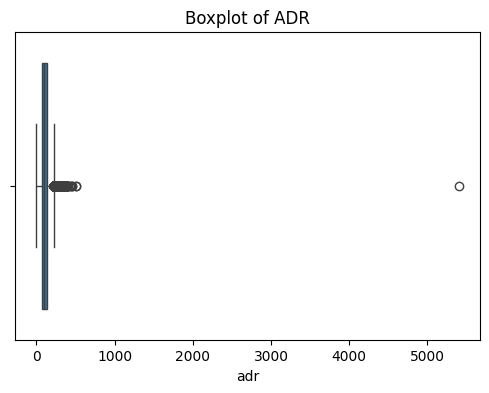

In [18]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['adr'])
plt.title("Boxplot of ADR")
plt.show()

In [19]:
Q1 = df['adr'].quantile(0.25)
Q3 = df['adr'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)


Lower Bound: -21.0
Upper Bound: 227.0


In [20]:
df = df[(df['adr'] >= lower_bound) & (df['adr'] <= upper_bound)]

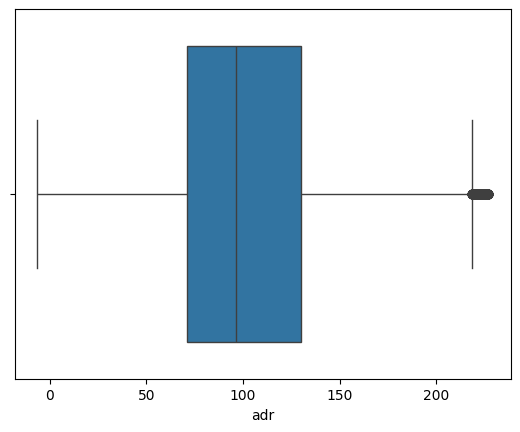

In [21]:
sns.boxplot(x=df['adr'])
plt.show()

#### Checking Distribution (Skewness)

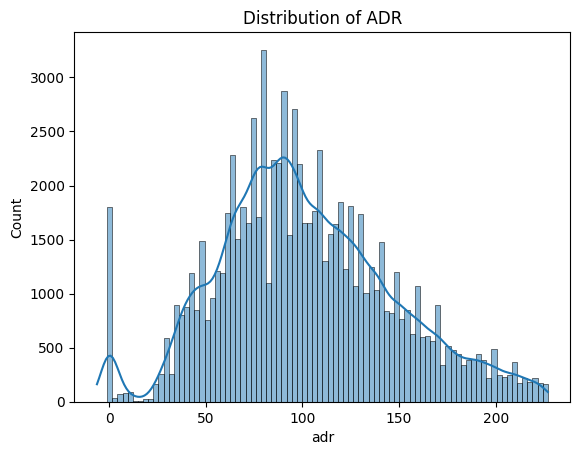

Skewness: 0.333942247753656


In [22]:
sns.histplot(df['adr'], kde=True)
plt.title("Distribution of ADR")
plt.show()

print("Skewness:", df['adr'].skew())

#### Skewness between -0.5 to +0.5 → Approximately normal distribution ADR = 0.33 → Slight right skew (very normal for price data) Distribution shape looks smooth and reasonable.

##### <span style="color: Blue;">The distribution of ADR was analyzed using histogram and skewness. Since skewness value <span style="color: Red;">(0.33)</span> is within acceptable range, no transformation was applied.</span>

In [23]:
corr_matrix = df.corr(numeric_only=True)
corr_with_target = corr_matrix['adr'].sort_values(ascending=False)
print(corr_with_target)

adr                               1.000000
children                          0.264002
adults                            0.258622
arrival_date_year                 0.165540
total_of_special_requests         0.152777
is_canceled                       0.133780
arrival_date_week_number          0.092211
stays_in_week_nights              0.046218
lead_time                         0.040116
stays_in_weekend_nights           0.035583
arrival_date_day_of_month         0.019398
required_car_parking_spaces       0.019292
babies                            0.019032
booking_changes                  -0.013415
days_in_waiting_list             -0.034806
previous_cancellations           -0.054588
agent                            -0.059632
previous_bookings_not_canceled   -0.096361
is_repeated_guest                -0.178055
Name: adr, dtype: float64


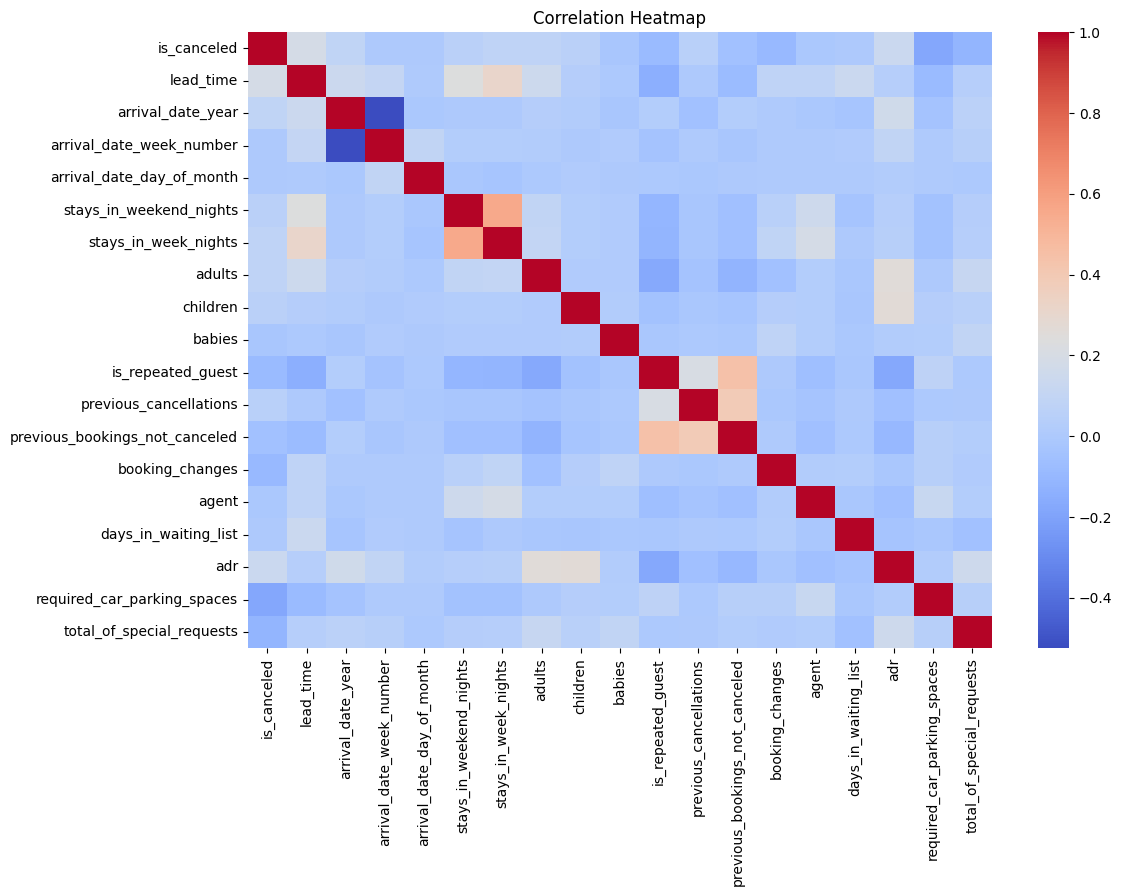

In [24]:
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

##### <span style="color: Blue;">Correlation analysis shows no strong linear relationship between ADR and any single feature. This suggests that room pricing is influenced by multiple factors rather than a single dominant variable.</span>

### <span style="color: Red;"> 7. **Feature Engineering:**</span>

#### Categorical Encoding

In [25]:
df.select_dtypes(include='object').columns

Index(['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment',
       'distribution_channel', 'reserved_room_type', 'assigned_room_type',
       'deposit_type', 'customer_type', 'reservation_status',
       'reservation_status_date'],
      dtype='object')

#### Dropped Data Leakage Columns

In [26]:
df.drop(['reservation_status', 
         'reservation_status_date'], axis=1, inplace=True)

In [27]:
df.drop('is_canceled', axis=1, inplace=True)

##### reservation_status_date and is_canceled happens after booking.It can introduce data leakage hence removed.

In [28]:
top_countries = df['country'].value_counts().index[:10]
df['country'] = df['country'].apply(lambda x: x if x in top_countries else 'Other')

#### One-hot encoding

In [29]:
df = pd.get_dummies(df, drop_first=True)

##### <span style="color: Blue;">Since the categorical variables are nominal and do not have an inherent order, One-Hot Encoding was used to convert them into numerical format without introducing ordinal bias.</span>

In [30]:
print("Shape after encoding:", df.shape)

Shape after encoding: (84906, 80)


#### Separated features and target

In [31]:
X = df.drop('adr', axis=1)
y = df['adr']
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (84906, 79)
y shape: (84906,)


### <span style="color: Red;">8. **Feature Selection:**  /  9. **Split Data into Training and Testing Sets:**</span>

In [32]:
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

selector = SelectKBest(score_func=f_regression, k=15)
X_train_selected = selector.fit_transform(X_train, y_train)

X_test_selected = selector.transform(X_test)

print("Selected Features Shape:", X_train_selected.shape)

X_train: (67924, 79)
X_test: (16982, 79)
y_train: (67924,)
y_test: (16982,)
Selected Features Shape: (67924, 15)


### <span style="color: Red;">10. **Feature Scaling:**</span>

In [33]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


### <span style="color: Red;">11. **Build the ML Model:** </span>

#### Linear Regression

In [35]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

#### Support Vector Regressor (SVR)

In [ ]:
from sklearn.svm import SVR

svr = SVR()
svr.fit(X_train, y_train)
y_pred_svr = svr.predict(X_test)

#### Random Forest Regressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

#### Gradient Boosting Regressor

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(X_train, y_train)
y_pred_gbr = gbr.predict(X_test)

#### AdaBoost Regressor

In [ ]:
from sklearn.ensemble import AdaBoostRegressor

abr = AdaBoostRegressor(random_state=42)
abr.fit(X_train, y_train)
y_pred_abr = abr.predict(X_test)

### <span style="color: Red;">12. **Model Evaluation:**</span>

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate_model(y_test, y_pred, model_name):
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    print(f"----- {model_name} -----")
    print("MAE:", mae)
    print("MSE :", mse)
    print("RMSE:", rmse)
    print("R2 Score:", r2)
    print()

In [ ]:
evaluate_model(y_test, y_pred_lr, "Linear Regression")
evaluate_model(y_test, y_pred_svr, "SVR")
evaluate_model(y_test, y_pred_rf, "Random Forest")
evaluate_model(y_test, y_pred_gbr, "Gradient Boosting")
evaluate_model(y_test, y_pred_abr, "AdaBoost")

### <span style="color: Red;"> 13. **Hyperparameter Tuning: and pipeline ** </span>

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

pipeline = Pipeline([
    ('rf', RandomForestRegressor(random_state=42))
])

param_grid = {
    'rf__n_estimators': [100, 200],
    'rf__max_depth': [None, 10, 20],
    'rf__min_samples_split': [2, 5],
    'rf__min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

In [ ]:
y_pred_best = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_best)
mse = mean_squared_error(y_test, y_pred_best)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_best)

print("Tuned Random Forest Performance")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2  :", r2)

##### <span style="color: Blue;">Hyperparameter tuning was performed using GridSearchCV with 5-fold cross-validation. The model parameters such as number of estimators, maximum depth, and minimum samples were optimized to improve predictive performance.</span>

### <span style="color: Red;"> 14. **Save the Model:**</span>

In [ ]:
import joblib

joblib.dump(best_model, "random_forest_adr_model.pkl")

### <span style="color: Red;">15. **Test with Unseen Data:**</span>

In [ ]:
sample = X_test.iloc[0:1]
prediction = best_model.predict(sample)

print("Predicted ADR:", prediction[0])
print("Actual ADR:", y_test.iloc[0])

### <span style="color:Red;">16. **Interpretation of Results (Conclusion):**</span>

##### <span style="color: blue;">Multiple regression models were implemented to predict the Average Daily Rate (ADR). Among all models tested, the Random Forest Regressor achieved the best performance with an R² score of 0.857 and lowest RMSE.This indicates that ensemble tree-based models are highly effective for capturing non-linear relationships in hotel booking data.The model successfully explains approximately 85% of the variance in ADR values.</span>
##### Limitations of the dataset:
##### 1. Dataset may contain missing values
##### 2. ADR distribution may be skewed
##### 3. No real-time seasonal updates
##### 4. External economic factors not included
##### 5.Some features may have multicollinearity

### <span style="color: Red;">17. **Future Work:**</span>

##### 1. Implement deep learning models such as Artificial Neural Networks for potentially higher predictive accuracy.
##### 2. Update the model periodically with new booking data to maintain performance.
##### 3. Address potential imbalanced patterns through advanced resampling techniques.
##### 4.Introduce additional features such as competitor pricing, seasonal demand index, or customer segmentation. 
##### 5. Deploy the model using a web application for real-time ADR prediction.
